In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# Generate data: one mean per commit
n_baseline_commits = 10
baseline_mean = 102.5
new_mean = 105
std = 0.4  # tight clustering for baseline

# Baseline commits (blue) - clustered between 102-103
baseline_points = np.random.normal(baseline_mean, std, n_baseline_commits)

# New commit (orange) - stands out at 105
new_point = 105.0

print(f"Baseline points: {baseline_points}")
print(f"Baseline mean: {baseline_points.mean():.1f}")
print(f"New commit: {new_point:.1f}")
print(f"Difference: {(new_point - baseline_points.mean()) / baseline_points.mean() * 100:.1f}%")

Baseline points: [102.69868566 102.44469428 102.75907542 103.10921194 102.40633865
 102.40634522 103.13168513 102.80697389 102.31221025 102.71702402]
Baseline mean: 102.7
New commit: 105.0
Difference: 2.3%


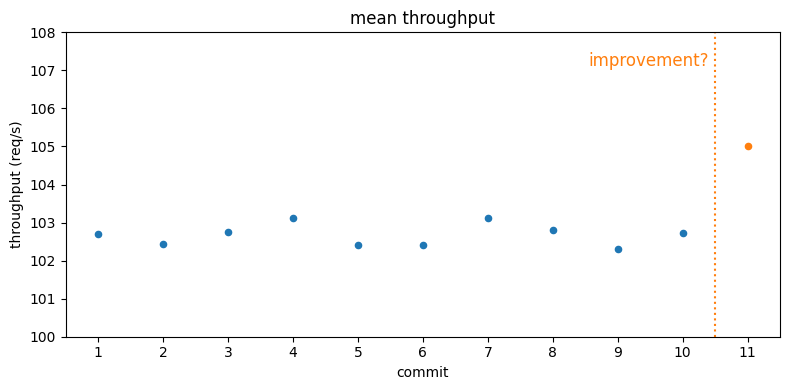

In [12]:
# Graph 1: Full timeseries - one point per commit
fig, ax = plt.subplots(figsize=(8, 4))

# Baseline commits (blue) - start at 1
x_baseline = np.arange(1, n_baseline_commits + 1)
ax.scatter(x_baseline, baseline_points, c='C0', s=20, zorder=3)

# New commit (orange) - right next to baseline
ax.scatter([n_baseline_commits + 1], [new_point], c='C1', s=20, zorder=3)

# Dotted line between commits 10 and 11 with label
ax.axvline(x=10.5, color='C1', linestyle=':', linewidth=1.5)
ax.text(10.4, 107, 'improvement?', ha='right', va='bottom', fontsize=12, color='C1')

ax.set_xlabel('commit')
ax.set_ylabel('throughput (req/s)')
ax.set_title('mean throughput')
ax.set_ylim(100, 108)
ax.set_xticks(range(1, n_baseline_commits + 2))
ax.set_xlim(0.5, n_baseline_commits + 1.5)
plt.tight_layout()
fig.savefig('../assets/interpreting-results-timeseries-full.svg')
plt.show()

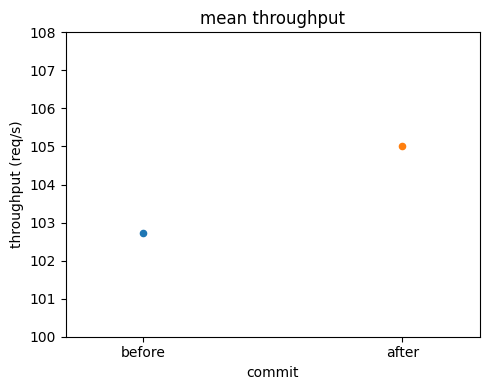

In [13]:
# Graph 2: Zoomed in on last two commits only
fig, ax = plt.subplots(figsize=(5, 4))

last_baseline = baseline_points[-1]

# Last baseline commit (blue)
ax.scatter([0], [last_baseline], c='C0', s=20, zorder=3)

# New commit (orange)
ax.scatter([1], [new_point], c='C1', s=20, zorder=3)

ax.set_xlabel('commit')
ax.set_ylabel('throughput (req/s)')
ax.set_title('mean throughput')
ax.set_ylim(100, 108)
ax.set_xticks([0, 1])
ax.set_xticklabels(['before', 'after'])
ax.set_xlim(-0.3, 1.3)
plt.tight_layout()
fig.savefig('../assets/interpreting-results-timeseries-zoom.svg')
plt.show()

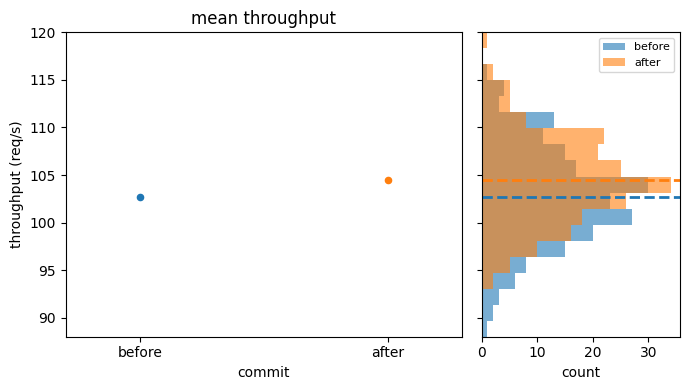

Before mean: 102.7, std: 5.3
After mean: 104.4, std: 4.6
t-statistic: -3.41
p-value: 0.0007
Significant at α=0.05? True


In [14]:
# Graph 3: Two commits with distributions overlaid on y-axis
# Need underlying samples for distributions
np.random.seed(123)
n_samples = 200
before_samples = np.random.normal(baseline_points[-1], 5, n_samples)
after_samples = np.random.normal(new_point, 5, n_samples)

fig, axes = plt.subplots(1, 2, figsize=(7, 4), gridspec_kw={'width_ratios': [2, 1]}, sharey=True)

ax_scatter = axes[0]
ax_hist = axes[1]

# Scatter plot - one point per commit (no mean lines)
ax_scatter.scatter([0], [before_samples.mean()], c='C0', s=20, zorder=3)
ax_scatter.scatter([1], [after_samples.mean()], c='C1', s=20, zorder=3)

ax_scatter.set_xlabel('commit')
ax_scatter.set_ylabel('throughput (req/s)')
ax_scatter.set_title('mean throughput')
ax_scatter.set_xticks([0, 1])
ax_scatter.set_xticklabels(['before', 'after'])
ax_scatter.set_xlim(-0.3, 1.3)

# Histograms on y-axis (rotated)
bins = np.linspace(88, 120, 20)
ax_hist.hist(before_samples, bins=bins, orientation='horizontal', alpha=0.6, color='C0', label='before')
ax_hist.hist(after_samples, bins=bins, orientation='horizontal', alpha=0.6, color='C1', label='after')
ax_hist.axhline(before_samples.mean(), color='C0', linestyle='--', linewidth=2)
ax_hist.axhline(after_samples.mean(), color='C1', linestyle='--', linewidth=2)
ax_hist.set_xlabel('count')
ax_hist.legend(loc='upper right', fontsize=8)

ax_scatter.set_ylim(88, 120)
plt.tight_layout()
fig.savefig('../assets/interpreting-results-with-distributions.svg')
plt.show()

# Stats
t_stat, p_value = stats.ttest_ind(before_samples, after_samples)
print(f"Before mean: {before_samples.mean():.1f}, std: {before_samples.std():.1f}")
print(f"After mean: {after_samples.mean():.1f}, std: {after_samples.std():.1f}")
print(f"t-statistic: {t_stat:.2f}")
print(f"p-value: {p_value:.4f}")
print(f"Significant at α=0.05? {p_value < 0.05}")

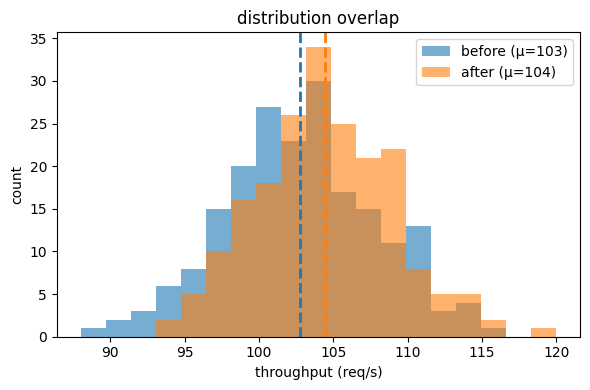

In [15]:
# Graph 4: Just the distributions (for hypothesis testing slide)
fig, ax = plt.subplots(figsize=(6, 4))

bins = np.linspace(88, 120, 20)
ax.hist(before_samples, bins=bins, alpha=0.6, color='C0', label=f'before (μ={before_samples.mean():.0f})')
ax.hist(after_samples, bins=bins, alpha=0.6, color='C1', label=f'after (μ={after_samples.mean():.0f})')
ax.axvline(before_samples.mean(), color='C0', linestyle='--', linewidth=2)
ax.axvline(after_samples.mean(), color='C1', linestyle='--', linewidth=2)

ax.set_xlabel('throughput (req/s)')
ax.set_ylabel('count')
ax.set_title('distribution overlap')
ax.legend()
plt.tight_layout()
fig.savefig('../assets/interpreting-results-distributions.svg')
plt.show()